**Dependencies**

In [1]:
pip install transformers==4.44.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 140.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
!pip install -U accelerate sentencepiece accelerate einops timm
!pip install -q tqdm

**Imports and setup**

In [3]:
import os
import random
import numpy as np
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForCausalLM

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


**Reproducability**

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

**Load dataset**

In [5]:
extract_path = "/content/dataset"

In [6]:


import zipfile
import os

!gdown "https://drive.google.com/uc?id=1qYNQgfEFuPa7L75TeuaO_Exc_rFBDF68"

zip_path = "/content/leftImg8bit_trainvaltest.zip"
extract_path = "/content/dataset"

# 3. Extract the dataset
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)


Downloading...
From (original): https://drive.google.com/uc?id=1qYNQgfEFuPa7L75TeuaO_Exc_rFBDF68
From (redirected): https://drive.google.com/uc?id=1qYNQgfEFuPa7L75TeuaO_Exc_rFBDF68&confirm=t&uuid=6ab6aaba-38e9-4c69-a903-eafe3f058986
To: /content/leftImg8bit_trainvaltest.zip
100% 11.6G/11.6G [02:55<00:00, 66.1MB/s]
Dataset extracted to: /content/dataset


**Load image paths**

In [7]:
def get_image_paths(folder):
    valid_ext = ('.jpg', '.jpeg', '.png')
    paths = []

    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(valid_ext):
                paths.append(os.path.join(root, file))

    return paths

image_paths = get_image_paths(extract_path)
print("Total images:", len(image_paths))

Total images: 5000


**Load florence-2 model**

In [9]:
from transformers import AutoProcessor, AutoModelForCausalLM
from transformers.dynamic_module_utils import get_imports
from unittest.mock import patch

model_id = "microsoft/Florence-2-base"

def fixed_get_imports(filename):
    if not str(filename).endswith("modeling_florence2.py"):
        return get_imports(filename)
    imports = get_imports(filename)
    if "flash_attn" in imports:
        imports.remove("flash_attn")
    return imports

processor = AutoProcessor.from_pretrained(
    model_id,
    trust_remote_code = True
)

with patch("transformers.dynamic_module_utils.get_imports", fixed_get_imports):
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        trust_remote_code=True,
        attn_implementation="sdpa"  # use PyTorch's built-in efficient attention instead
    ).to(device).eval()



print("Model loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

processing_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-base:
- processing_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json:   0%|          | 0.00/34.0 [00:00<?, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-base:
- configuration_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


modeling_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-base:
- modeling_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/463M [00:00<?, ?B/s]

Model loaded successfully!


**Captioning function**

In [10]:
def generate_caption(image_path, prompt="<DETAILED_CAPTION>"):
    image = Image.open(image_path).convert("RGB")

    inputs = processor(
        text=prompt,
        images=image,
        return_tensors="pt"
    ).to(device)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=80,
        num_beams=3
    )

    generated_text = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0]

    return generated_text

**Test on sample images**

In [11]:
sample_images = image_paths[:5]

for img_path in sample_images:
    caption = generate_caption(img_path)
    print(f"\nImage: {img_path}")
    print("Caption:", caption)


Image: /content/dataset/leftImg8bit/train/krefeld/krefeld_000000_009574_leftImg8bit.png
Caption: The image shows a car driving down a street lined with tall buildings on either side. There are people walking on the footpath, a fence, plants, trees, sign boards, poles, traffic signals, and other objects. In the background, the sky can be seen.

Image: /content/dataset/leftImg8bit/train/krefeld/krefeld_000000_024921_leftImg8bit.png
Caption: The image shows a street with cars parked on the side of it. There is a van and a car in the foreground, and in the background there are buildings with windows and doors. The sky is visible at the top of the image.

Image: /content/dataset/leftImg8bit/train/krefeld/krefeld_000000_017042_leftImg8bit.png
Caption: The image shows a car driving down a street lined with tall buildings on either side. There are people walking on the footpath, vehicles driving on the road, and trees lining the sides of the street. The sky is visible in the background.

Imag

**Visualize results**

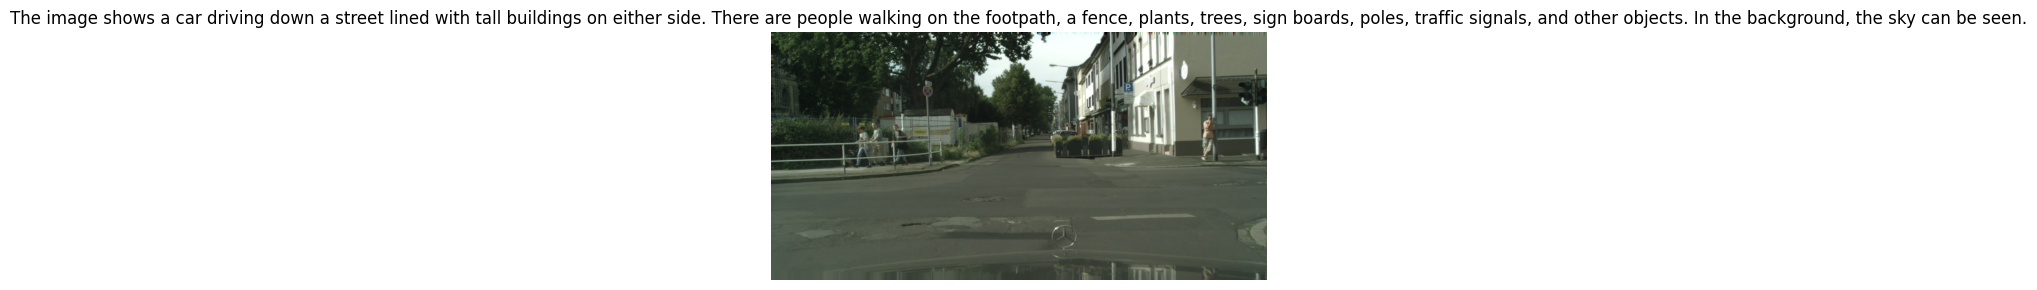

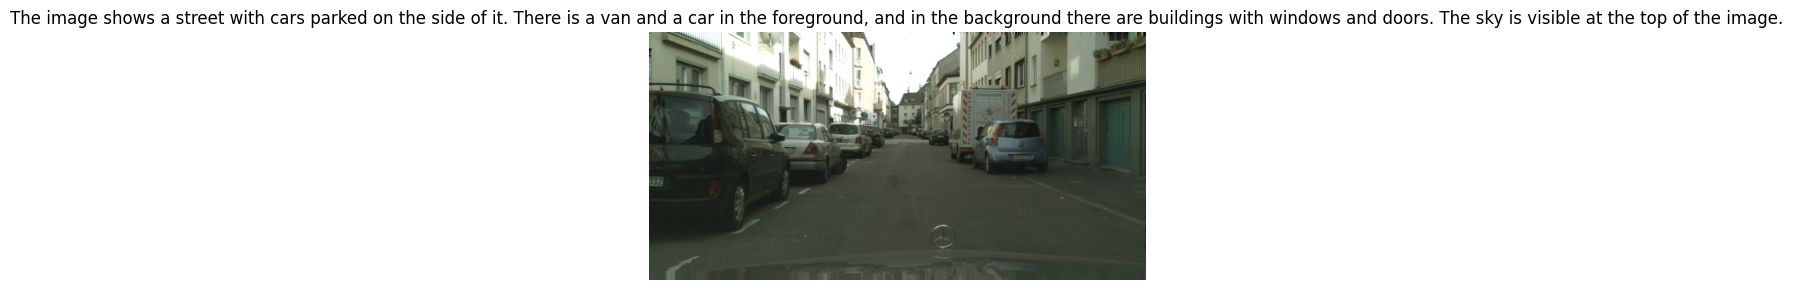

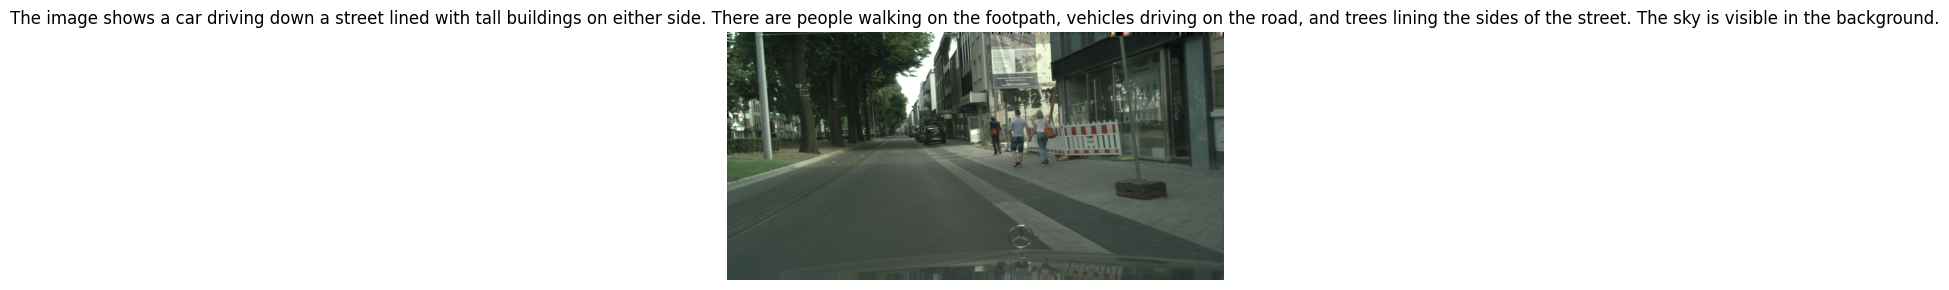

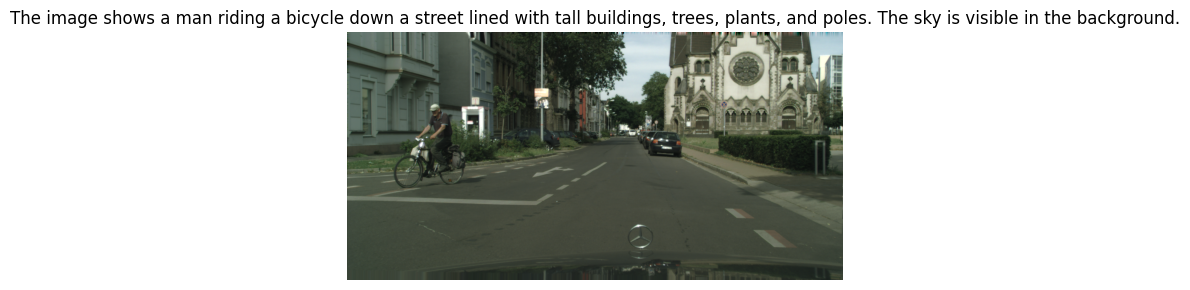

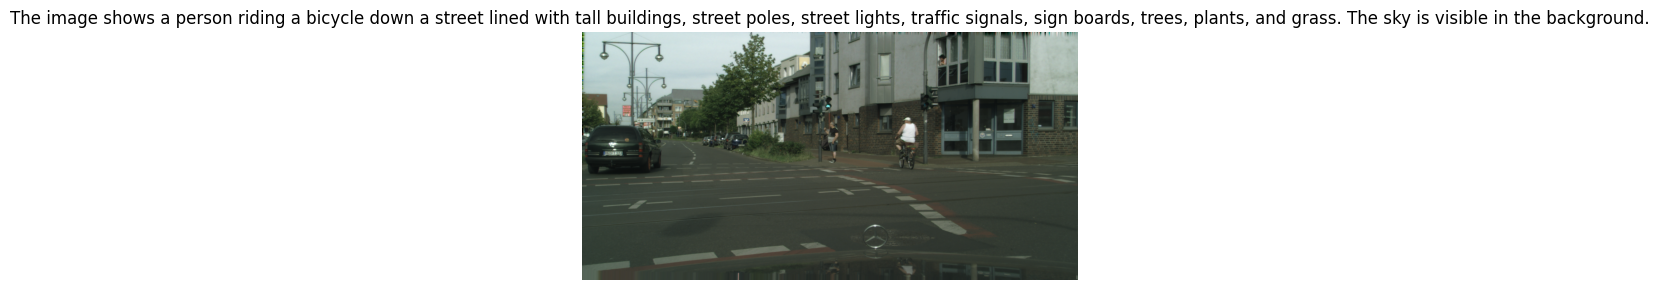

In [12]:
import matplotlib.pyplot as plt

def show_image_with_caption(image_path, caption):
    image = Image.open(image_path)

    plt.imshow(image)
    plt.axis("off")
    plt.title(caption)
    plt.show()

for img_path in sample_images:
    caption = generate_caption(img_path)
    show_image_with_caption(img_path, caption)

**Batch caption generation**

In [13]:
from tqdm import tqdm
import pandas as pd

results = []

for img_path in tqdm(image_paths, desc="Generating captions"):
    caption = generate_caption(img_path)
    results.append((img_path, caption))

df = pd.DataFrame(results, columns=["image", "caption"])
df.to_csv("captions.csv", index=False)

print("Saved captions to captions.csv")

Generating captions: 100%|██████████| 5000/5000 [1:08:01<00:00,  1.23it/s]

Saved captions to captions.csv


**Testing the caption lengths**

In [14]:
captions = df["caption"].tolist()

In [15]:
tokenizer = processor.tokenizer

In [16]:
import numpy as np

token_lengths = []
word_lengths = []

longest_token_caption = ""
shortest_token_caption = ""
longest_word_caption = ""
shortest_word_caption = ""

max_tokens = 0
min_tokens = float("inf")
max_words = 0
min_words = float("inf")

for caption in captions:
    # Token length
    tokens = tokenizer.encode(caption, add_special_tokens=False)
    token_len = len(tokens)
    token_lengths.append(token_len)

    # Word length
    words = caption.split()
    word_len = len(words)
    word_lengths.append(word_len)

    # Track extremes (tokens)
    if token_len > max_tokens:
        max_tokens = token_len
        longest_token_caption = caption

    if token_len < min_tokens:
        min_tokens = token_len
        shortest_token_caption = caption

    # Track extremes (words)
    if word_len > max_words:
        max_words = word_len
        longest_word_caption = caption

    if word_len < min_words:
        min_words = word_len
        shortest_word_caption = caption

In [17]:
print("📊 TOKEN STATS")
print(f"Average tokens: {np.mean(token_lengths):.2f}")
print("Max tokens:", max_tokens)
print("Min tokens:", min_tokens)

print("\n📊 WORD STATS")
print(f"Average words: {np.mean(word_lengths):.2f}")
print("Max words:", max_words)
print("Min words:", min_words)

📊 TOKEN STATS
Average tokens: 46.53
Max tokens: 78
Min tokens: 22

📊 WORD STATS
Average words: 40.04
Max words: 69
Min words: 20


In [18]:
print("\n🔝 Longest (tokens):")
print(longest_token_caption)

print("\n🔻 Shortest (tokens):")
print(shortest_token_caption)

print("\n🔝 Longest (words):")
print(longest_word_caption)

print("\n🔻 Shortest (words):")
print(shortest_word_caption)


🔝 Longest (tokens):
The image shows a house with a car parked in front of it on the side of the road. The house has windows, doors, steps, railings, and a roof, and is surrounded by plants, grass, a group of trees, a signboard attached to a pole, some stones, and the bark of a tree. The sky looks cloudy, adding to the atmosphere of the

🔻 Shortest (tokens):
The image shows a black car driving down a street lined with trees and plants, with buildings in the background.

🔝 Longest (words):
The image shows a woman walking down a street next to a car. On the left side of the image there are plants and trees, and on the right side there is a railing. In the background there are buildings with windows and doors, and there are sign boards with poles. At the bottom of the picture there is an object, and the woman is wearing a walking shoe.

🔻 Shortest (words):
The image shows a black car driving down a street lined with trees and plants, with buildings in the background.


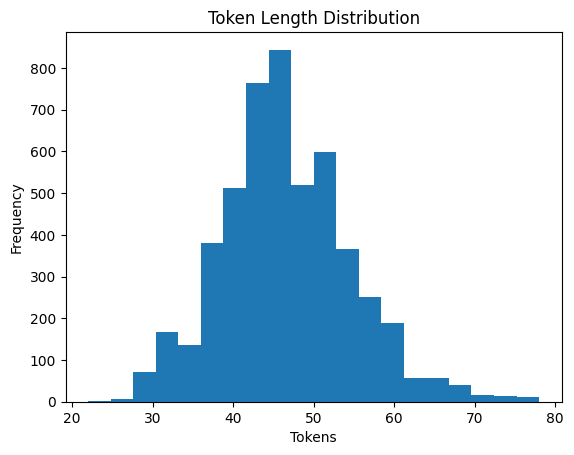

In [19]:
import matplotlib.pyplot as plt

plt.hist(token_lengths, bins=20)
plt.title("Token Length Distribution")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.show()